In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table
import utils.data_processing_bronze_table_others
import utils.data_processing_silver_table_others
import utils.data_processing_silver_table_attributes
import utils.data_processing_silver_table_clickstream
import utils.data_processing_gold_table_features

## set up pyspark session

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/21 13:03:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## set up config

In [3]:
# set up config
snapshot_date_str = "2023-01-01"

start_date_str = "2023-01-01"
end_date_str = "2025-01-01" #2024-12-01

In [4]:
# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    # Convert the date strings to datetime objects
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    # List to store the first of month dates
    first_of_month_dates = []

    # Start from the first of the month of the start_date
    current_date = datetime(start_date.year, start_date.month, 1)

    while current_date <= end_date:
        # Append the date in yyyy-mm-dd format
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        
        # Move to the first of the next month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
dates_str_lst

['2023-01-01',
 '2023-02-01',
 '2023-03-01',
 '2023-04-01',
 '2023-05-01',
 '2023-06-01',
 '2023-07-01',
 '2023-08-01',
 '2023-09-01',
 '2023-10-01',
 '2023-11-01',
 '2023-12-01',
 '2024-01-01',
 '2024-02-01',
 '2024-03-01',
 '2024-04-01',
 '2024-05-01',
 '2024-06-01',
 '2024-07-01',
 '2024-08-01',
 '2024-09-01',
 '2024-10-01',
 '2024-11-01',
 '2024-12-01',
 '2025-01-01']

## Build Bronze Table

In [5]:
# create bronze datalake
bronze_lms_directory = "datamart/bronze/lms/"

if not os.path.exists(bronze_lms_directory):
    os.makedirs(bronze_lms_directory)

In [6]:
# run bronze backfill
for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_lms_directory, spark)


2023-01-01row count: 530


saved to: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv
2023-02-01row count: 1031
saved to: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv
2023-03-01row count: 1537
saved to: datamart/bronze/lms/bronze_loan_daily_2023_03_01.csv
2023-04-01row count: 2047
saved to: datamart/bronze/lms/bronze_loan_daily_2023_04_01.csv
2023-05-01row count: 2568
saved to: datamart/bronze/lms/bronze_loan_daily_2023_05_01.csv
2023-06-01row count: 3085
saved to: datamart/bronze/lms/bronze_loan_daily_2023_06_01.csv
2023-07-01row count: 3556
saved to: datamart/bronze/lms/bronze_loan_daily_2023_07_01.csv
2023-08-01row count: 4037
saved to: datamart/bronze/lms/bronze_loan_daily_2023_08_01.csv
2023-09-01row count: 4491
saved to: datamart/bronze/lms/bronze_loan_daily_2023_09_01.csv
2023-10-01row count: 4978
saved to: datamart/bronze/lms/bronze_loan_daily_2023_10_01.csv
2023-11-01row count: 5469
saved to: datamart/bronze/lms/bronze_loan_daily_2023_11_01.csv
2023-12-01row count: 5428
saved to: datamart/br

In [7]:
# inspect output
utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_lms_directory, spark).toPandas()

2025-01-01row count: 5539
saved to: datamart/bronze/lms/bronze_loan_daily_2025_01_01.csv


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,CUS_0x1009_2025_01_01,CUS_0x1009,2025-01-01,10,0,10000,0.0,0.0,0.0,10000.0,2025-01-01
1,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,10,10000,1000.0,1000.0,0.0,0.0,2025-01-01
2,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,9,10000,1000.0,0.0,7000.0,8000.0,2025-01-01
3,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,3,10000,1000.0,1000.0,0.0,7000.0,2025-01-01
4,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,1,10000,1000.0,1000.0,0.0,9000.0,2025-01-01
...,...,...,...,...,...,...,...,...,...,...,...
5534,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,9,10000,1000.0,1000.0,0.0,1000.0,2025-01-01
5535,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,7,10000,1000.0,1000.0,0.0,3000.0,2025-01-01
5536,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,1,10000,1000.0,1000.0,0.0,9000.0,2025-01-01
5537,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,3,10000,1000.0,1000.0,0.0,7000.0,2025-01-01


In [8]:
# import utils.data_processing_bronze_table_others
file_path = "data/feature_clickstream.csv"
bronze_clickstream_directory = "datamart/bronze/clickstream/"

if not os.path.exists(bronze_clickstream_directory):
    os.makedirs(bronze_clickstream_directory)
    
for date_str in dates_str_lst:
    utils.data_processing_bronze_table_others.process_bronze_table(date_str, bronze_clickstream_directory, file_path, spark)

2023-01-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_feature_clickstream_2023_01_01.csv
2023-02-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_feature_clickstream_2023_02_01.csv
2023-03-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_feature_clickstream_2023_03_01.csv
2023-04-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_feature_clickstream_2023_04_01.csv
2023-05-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_feature_clickstream_2023_05_01.csv
2023-06-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_feature_clickstream_2023_06_01.csv
2023-07-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_feature_clickstream_2023_07_01.csv
2023-08-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_feature_clickstream_2023_08_01.csv
2023-09-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_feature_clickstream_2023_09_01.csv
2023-10-01row count: 8974
saved to: datamart/b

In [9]:
# inspect output
utils.data_processing_bronze_table_others.process_bronze_table(date_str, bronze_clickstream_directory, file_path, spark).toPandas()

2025-01-01row count: 0
saved to: datamart/bronze/clickstream/bronze_feature_clickstream_2025_01_01.csv


,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date


In [10]:
# Load clickstream data with Spark
df_clickstream = spark.read.csv("data/feature_clickstream.csv", header=True, inferSchema=True)

print("Shape:", (df_clickstream.count(), len(df_clickstream.columns)))
print("\nColumns:", df_clickstream.columns)
print("\nFirst few rows:")
df_clickstream.show(10, truncate=False)
print("\nSchema:")
df_clickstream.printSchema()

Shape: (215376, 22)

Columns: ['fe_1', 'fe_2', 'fe_3', 'fe_4', 'fe_5', 'fe_6', 'fe_7', 'fe_8', 'fe_9', 'fe_10', 'fe_11', 'fe_12', 'fe_13', 'fe_14', 'fe_15', 'fe_16', 'fe_17', 'fe_18', 'fe_19', 'fe_20', 'Customer_ID', 'snapshot_date']

First few rows:
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|fe_1|fe_2|fe_3|fe_4|fe_5|fe_6|fe_7|fe_8|fe_9|fe_10|fe_11|fe_12|fe_13|fe_14|fe_15|fe_16|fe_17|fe_18|fe_19|fe_20|Customer_ID|snapshot_date|
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|63  |118 |80  |121 |55  |193 |111 |112 |-101|83   |164  |105  |-16  |-81  |-126 |114  |35   |85   |-73  |76   |CUS_0x1037 |2023-01-01   |
|-108|182 |123 |4   |-56 |27  |25  |-6  |284 |222  |203  |190  |-14  |-96  |200  |35   |130  |94   |111  |75   |CUS_0x1069 |2023-01-01   |
|-13 |8   |87  |166 |214 |-98 |215 |152 |129 |139  |14

In [11]:
# Feature statistics and correlation analysis with Spark
from pyspark.sql.functions import countDistinct, min, max

feature_cols = [f'fe_{i}' for i in range(1, 21)]

print("=== Feature Statistics ===")
df_clickstream.select(feature_cols).describe().show()

print("\n=== Unique Values ===")
unique_cust = df_clickstream.select(countDistinct("Customer_ID")).collect()[0][0]
unique_dates = df_clickstream.select(countDistinct("snapshot_date")).collect()[0][0]
min_date = df_clickstream.select(min("snapshot_date")).collect()[0][0]
max_date = df_clickstream.select(max("snapshot_date")).collect()[0][0]

print(f"Unique customers: {unique_cust}")
print(f"Unique dates: {unique_dates}")
print(f"Date range: {min_date} to {max_date}")

print("\n=== Check for Correlation Among Features ===")
# Convert to pandas for correlation matrix calculation
pdf_features = df_clickstream.select(feature_cols).toPandas()
corr_matrix = pdf_features.corr()

print("Features with high correlation (> 0.8):")
high_corr_found = False
for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
                    if abs(corr_matrix.iloc[i, j]) > 0.8:
                                    print(f"  {corr_matrix.columns[i]} - {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")
                                    high_corr_found = True

if not high_corr_found:
    print("  None found - all features are independent!")

=== Feature Statistics ===


+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|summary|              fe_1|              fe_2|              fe_3|              fe_4|              fe_5|              fe_6|              fe_7|              fe_8|              fe_9|             fe_10|             fe_11|             fe_12|            fe_13|             fe_14|             fe_15|             fe_16|             fe_17|             fe_18|             fe_19|             fe_20|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+----

In [12]:
# Load clickstream data with Spark
df_attributes = spark.read.csv("data/features_attributes.csv", header=True, inferSchema=True)

print("Shape:", (df_attributes.count(), len(df_attributes.columns)))
print("\nColumns:", df_attributes.columns)
print("\nFirst few rows:")
df_attributes.show(10, truncate=False)
print("\nSchema:")
df_attributes.printSchema()

Shape: (12500, 6)

Columns: ['Customer_ID', 'Name', 'Age', 'SSN', 'Occupation', 'snapshot_date']

First few rows:
+-----------+----------------+---+-----------+-------------+-------------+
|Customer_ID|Name            |Age|SSN        |Occupation   |snapshot_date|
+-----------+----------------+---+-----------+-------------+-------------+
|CUS_0x1000 |Alistair Barrf  |18 |913-74-1218|Lawyer       |2023-05-01   |
|CUS_0x1009 |Arunah          |26 |063-67-6938|Mechanic     |2025-01-01   |
|CUS_0x100b |Shirboni        |19 |#F%$D@*&8  |Media_Manager|2024-03-01   |
|CUS_0x1011 |Schneyerh       |44 |793-05-8223|Doctor       |2023-11-01   |
|CUS_0x1013 |Cameront        |44 |930-49-9615|Mechanic     |2023-12-01   |
|CUS_0x1015 |Holtono         |27 |810-97-7024|Journalist   |2023-08-01   |
|CUS_0x1018 |Felsenthalq     |15 |731-19-8119|Accountant   |2023-11-01   |
|CUS_0x1026 |Josephv         |52 |500-62-9044|Manager      |2023-10-01   |
|CUS_0x102d |Neil Chatterjeex|31 |692-71-7552|Entrepreneur |2

In [13]:
df_attributes.select(countDistinct("occupation").alias("num_occupations")).show()

+---------------+
|num_occupations|
+---------------+
|             16|
+---------------+



In [14]:
file_path = "data/features_attributes.csv"
bronze_attributes_directory = "datamart/bronze/attributes/"

if not os.path.exists(bronze_attributes_directory):
    os.makedirs(bronze_attributes_directory)
    
for date_str in dates_str_lst:
    utils.data_processing_bronze_table_others.process_bronze_table(date_str, bronze_attributes_directory, file_path, spark)

2023-01-01row count: 530
saved to: datamart/bronze/attributes/bronze_feature_attributes_2023_01_01.csv
2023-02-01row count: 501
saved to: datamart/bronze/attributes/bronze_feature_attributes_2023_02_01.csv
2023-03-01row count: 506
saved to: datamart/bronze/attributes/bronze_feature_attributes_2023_03_01.csv
2023-04-01row count: 510
saved to: datamart/bronze/attributes/bronze_feature_attributes_2023_04_01.csv
2023-05-01row count: 521
saved to: datamart/bronze/attributes/bronze_feature_attributes_2023_05_01.csv
2023-06-01row count: 517
saved to: datamart/bronze/attributes/bronze_feature_attributes_2023_06_01.csv
2023-07-01row count: 471
saved to: datamart/bronze/attributes/bronze_feature_attributes_2023_07_01.csv
2023-08-01row count: 481
saved to: datamart/bronze/attributes/bronze_feature_attributes_2023_08_01.csv
2023-09-01row count: 454
saved to: datamart/bronze/attributes/bronze_feature_attributes_2023_09_01.csv
2023-10-01row count: 487
saved to: datamart/bronze/attributes/bronze_feat

In [15]:
utils.data_processing_bronze_table_others.process_bronze_table(date_str, bronze_attributes_directory, file_path, spark).toPandas()

2025-01-01row count: 526
saved to: datamart/bronze/attributes/bronze_feature_attributes_2025_01_01.csv


,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x1009,Arunah,26,063-67-6938,Mechanic,2025-01-01
1,CUS_0x1098,Krudyz,23,466-10-5742,_______,2025-01-01
2,CUS_0x109f,Vellacottj,41,283-32-0255,Teacher,2025-01-01
3,CUS_0x10b6,Gillesw,49,439-76-5364,Journalist,2025-01-01
4,CUS_0x10e2,Sonalio,37,168-78-3262,Media_Manager,2025-01-01
...,...,...,...,...,...,...
521,CUS_0xf15,Frankeld,26,881-11-1453,Developer,2025-01-01
522,CUS_0xf60,Ingrams,17,929-19-3979,Lawyer,2025-01-01
523,CUS_0xf74,Andrew Callusd,19,355-58-6584,Doctor,2025-01-01
524,CUS_0xf95,Alexei Anishchukz,17_,082-42-3634,Entrepreneur,2025-01-01


In [16]:
file_path = "data/features_financials.csv"
bronze_financials_directory = "datamart/bronze/financials/"

if not os.path.exists(bronze_financials_directory):
    os.makedirs(bronze_financials_directory)
    
for date_str in dates_str_lst:
    utils.data_processing_bronze_table_others.process_bronze_table(date_str, bronze_financials_directory, file_path, spark)

2023-01-01row count: 530
saved to: datamart/bronze/financials/bronze_feature_financials_2023_01_01.csv
2023-02-01row count: 501
saved to: datamart/bronze/financials/bronze_feature_financials_2023_02_01.csv
2023-03-01row count: 506
saved to: datamart/bronze/financials/bronze_feature_financials_2023_03_01.csv
2023-04-01row count: 510
saved to: datamart/bronze/financials/bronze_feature_financials_2023_04_01.csv
2023-05-01row count: 521
saved to: datamart/bronze/financials/bronze_feature_financials_2023_05_01.csv
2023-06-01row count: 517
saved to: datamart/bronze/financials/bronze_feature_financials_2023_06_01.csv
2023-07-01row count: 471
saved to: datamart/bronze/financials/bronze_feature_financials_2023_07_01.csv
2023-08-01row count: 481
saved to: datamart/bronze/financials/bronze_feature_financials_2023_08_01.csv
2023-09-01row count: 454
saved to: datamart/bronze/financials/bronze_feature_financials_2023_09_01.csv
2023-10-01row count: 487
saved to: datamart/bronze/financials/bronze_feat

In [17]:
utils.data_processing_bronze_table_others.process_bronze_table(date_str, bronze_financials_directory, file_path, spark).toPandas()

2025-01-01row count: 526
saved to: datamart/bronze/financials/bronze_feature_financials_2025_01_01.csv


,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x1009,52312.68_,4250.390000,6,5,17,4,"Not Specified, Home Equity Loan, Credit-Builde...",5,18,...,_,202.68,40.286997,31 Years and 0 Months,Yes,108.366467,58.66019164829086,High_spent_Medium_value_payments,508.01234122645366,2025-01-01
1,CUS_0x1098,20652.98_,1468.081667,7,5,21,2,"Auto Loan, and Payday Loan",24,10,...,Standard,1859.53,37.441101,18 Years and 11 Months,NM,33.238356,54.60338563277085,Low_spent_Small_value_payments,348.96642479393626,2025-01-01
2,CUS_0x109f,130435.86000000002,10623.655000,4,846,9,2,"Home Equity Loan, and Home Equity Loan",13,1,...,Good,942.71,34.784704,29 Years and 11 Months,NM,188.186133,1070.730679227028,Low_spent_Medium_value_payments,81.1419359951725,2025-01-01
3,CUS_0x10b6,5691341.0,1712.969167,7,3,19,3,"Payday Loan, Credit-Builder Loan, and Debt Con...",6,12,...,Standard,277.93,40.278541,18 Years and 4 Months,No,37.996378,65.372164147804,High_spent_Small_value_payments,327.9283743913377,2025-01-01
4,CUS_0x10e2,43133.85000000001,3432.487500,10,10,31,7,"Personal Loan, Auto Loan, Not Specified, Home ...",43,24,...,Bad,2504.1,27.115861,10 Years and 9 Months,Yes,151.287255,67.89250966068741,High_spent_Large_value_payments,364.0689853638198,2025-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521,CUS_0xf15,45652.17,3888.347500,8,6,13,7,"Mortgage Loan, Payday Loan, Debt Consolidation...",10,10,...,_,28.54,26.846632,10 Years and 11 Months,Yes,160.473304,154.47086437898875,Low_spent_Medium_value_payments,353.8905820472088,2025-01-01
522,CUS_0xf60,34413.76,2916.813333,6,5,8,5,"Home Equity Loan, Home Equity Loan, Home Equit...",23,20,...,_,113.06,24.508003,6 Years and 4 Months,Yes,74.328709,330.7631176311532,Low_spent_Small_value_payments,176.5895062534961,2025-01-01
523,CUS_0xf74,17111.35,1367.645556,10,6,3868,7,"Personal Loan, Mortgage Loan, Home Equity Loan...",55,25,...,Bad,1763.48,25.724679,19 Years and 0 Months,Yes,95.734001,55.60022588346901,Low_spent_Medium_value_payments,264.66063434363843,2025-01-01
524,CUS_0xf95,15604.56,1389.380000,9,5,25,3,"Debt Consolidation Loan, Home Equity Loan, and...",27,23,...,Bad,2686.18,35.184082,19 Years and 10 Months,Yes,37.912350,92.1139885286824,Low_spent_Small_value_payments,298.9116613286117,2025-01-01


## Build Silver Table

In [18]:
# create bronze datalake
silver_loan_daily_directory = "datamart/silver/loan_daily/"

if not os.path.exists(silver_loan_daily_directory):
    os.makedirs(silver_loan_daily_directory)

In [19]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table.process_silver_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark)


loaded from: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv row count: 530


saved to: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv row count: 1031
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_03_01.csv row count: 1537
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_03_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_04_01.csv row count: 2047
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_04_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_05_01.csv row count: 2568
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_05_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_06_01.csv row count: 3085
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_06_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_07_01.csv row count: 3556
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_07_0

In [20]:
utils.data_processing_silver_table.process_silver_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark).toPandas()

loaded from: datamart/bronze/lms/bronze_loan_daily_2025_01_01.csv row count: 5539
saved to: datamart/silver/loan_daily/silver_loan_daily_2025_01_01.parquet


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd
0,CUS_0x1009_2025_01_01,CUS_0x1009,2025-01-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2025-01-01,0,0,None,0
1,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,10,10000.0,1000.0,1000.0,0.0,0.0,2025-01-01,10,0,None,0
2,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,9,10000.0,1000.0,0.0,7000.0,8000.0,2025-01-01,9,7,2024-06-01,214
3,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,3,10000.0,1000.0,1000.0,0.0,7000.0,2025-01-01,3,0,None,0
4,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,1,10000.0,1000.0,1000.0,0.0,9000.0,2025-01-01,1,0,None,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5534,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,9,10000.0,1000.0,1000.0,0.0,1000.0,2025-01-01,9,0,None,0
5535,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,7,10000.0,1000.0,1000.0,0.0,3000.0,2025-01-01,7,0,None,0
5536,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,1,10000.0,1000.0,1000.0,0.0,9000.0,2025-01-01,1,0,None,0
5537,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,3,10000.0,1000.0,1000.0,0.0,7000.0,2025-01-01,3,0,None,0


In [21]:
silver_financials_directory = "datamart/silver/financials/"

if not os.path.exists(silver_financials_directory):
    os.makedirs(silver_financials_directory)

In [22]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table_others.process_silver_table(date_str, bronze_financials_directory, "financials", silver_financials_directory, spark)

loaded from: datamart/bronze/financials/bronze_feature_financials_2023_01_01.csv row count: 530
Column Annual_Income: 2 invalid values
Column Monthly_Inhand_Salary: 0 invalid values
Column Interest_Rate: 0 invalid values
Column Num_of_Loan: 0 invalid values
Column Delay_from_due_date: 0 invalid values
Column Num_of_Delayed_Payment: 0 invalid values
Column Amount_invested_monthly: 0 invalid values
Column Outstanding_Debt: 0 invalid values
Column Monthly_Balance: 0 invalid values


saved to: datamart/silver/financials/financials2023_01_01.parquet
loaded from: datamart/bronze/financials/bronze_feature_financials_2023_02_01.csv row count: 501
Column Annual_Income: 4 invalid values
Column Monthly_Inhand_Salary: 0 invalid values
Column Interest_Rate: 0 invalid values
Column Num_of_Loan: 0 invalid values
Column Delay_from_due_date: 0 invalid values
Column Num_of_Delayed_Payment: 0 invalid values
Column Amount_invested_monthly: 0 invalid values
Column Outstanding_Debt: 0 invalid values
Column Monthly_Balance: 0 invalid values
saved to: datamart/silver/financials/financials2023_02_01.parquet
loaded from: datamart/bronze/financials/bronze_feature_financials_2023_03_01.csv row count: 506
Column Annual_Income: 4 invalid values
Column Monthly_Inhand_Salary: 0 invalid values
Column Interest_Rate: 0 invalid values
Column Num_of_Loan: 0 invalid values
Column Delay_from_due_date: 0 invalid values
Column Num_of_Delayed_Payment: 0 invalid values
Column Amount_invested_monthly: 0 

saved to: datamart/silver/financials/financials2024_07_01.parquet
loaded from: datamart/bronze/financials/bronze_feature_financials_2024_08_01.csv row count: 543
Column Annual_Income: 5 invalid values
Column Monthly_Inhand_Salary: 0 invalid values
Column Interest_Rate: 0 invalid values
Column Num_of_Loan: 0 invalid values
Column Delay_from_due_date: 0 invalid values
Column Num_of_Delayed_Payment: 0 invalid values
Column Amount_invested_monthly: 0 invalid values
Column Outstanding_Debt: 0 invalid values
Column Monthly_Balance: 0 invalid values
saved to: datamart/silver/financials/financials2024_08_01.parquet
loaded from: datamart/bronze/financials/bronze_feature_financials_2024_09_01.csv row count: 493
Column Annual_Income: 6 invalid values
Column Monthly_Inhand_Salary: 0 invalid values
Column Interest_Rate: 0 invalid values
Column Num_of_Loan: 0 invalid values
Column Delay_from_due_date: 0 invalid values
Column Num_of_Delayed_Payment: 0 invalid values
Column Amount_invested_monthly: 0 

In [23]:
df_financials = utils.data_processing_silver_table_others.process_silver_table(date_str, bronze_financials_directory, "financials", silver_financials_directory, spark).toPandas()

loaded from: datamart/bronze/financials/bronze_feature_financials_2025_01_01.csv row count: 526
Column Annual_Income: 1 invalid values
Column Monthly_Inhand_Salary: 0 invalid values
Column Interest_Rate: 0 invalid values
Column Num_of_Loan: 0 invalid values
Column Delay_from_due_date: 0 invalid values
Column Num_of_Delayed_Payment: 0 invalid values
Column Amount_invested_monthly: 0 invalid values
Column Outstanding_Debt: 0 invalid values
Column Monthly_Balance: 0 invalid values
saved to: datamart/silver/financials/financials2025_01_01.parquet


In [24]:
df_financials.head()

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date,monthly_inhand_salary_vec,monthly_inhand_salary_vec_scaled
0,CUS_0x770a,29327.099609,2457.925049,6,6,18.0,5.0,"Credit-Builder Loan, Debt Consolidation Loan, ...",11.0,18.0,...,32.468003,18 Years and 11 Months,NM,74.115120,188.576492,Low_spent_Large_value_payments,253.100891,2025-01-01,[2457.925048828125],[-0.532435983896706]
1,CUS_0x976a,122069.007812,10115.417969,4,5,6.0,4.0,"Credit-Builder Loan, Auto Loan, Credit-Builder...",6.0,11.0,...,32.936699,31 Years and 2 Months,No,276.625490,408.710693,!@9#%8,576.205566,2025-01-01,[10115.41796875],[2.0044098656495013]
2,CUS_0x9e45,16252.485352,1514.373779,1,4,2.0,1.0,Personal Loan,3.0,9.0,...,38.580191,25 Years and 3 Months,NM,11.698358,118.849174,Low_spent_Small_value_payments,310.889832,2025-01-01,[1514.373779296875],[-0.8450244703603443]
3,CUS_0x4f2e,62031.058594,5295.254883,4,4,5469.0,4.0,"Home Equity Loan, Personal Loan, Not Specified...",15.0,20.0,...,27.260728,18 Years and 3 Months,No,160.207941,520.915283,High_spent_Large_value_payments,479.368500,2025-01-01,[5295.2548828125],[0.4075411716042522]
4,CUS_0xa9fc,66095.882812,4922.349121,7,4,10.0,4.0,"Home Equity Loan, Payday Loan, Student Loan, a...",18.0,17.0,...,24.226905,8 Years and 5 Months,Yes,822.996754,574.343018,Low_spent_Medium_value_payments,56.500225,2025-01-01,[4922.34912109375],[0.284001464316122]


In [25]:
df_financials[["Annual_Income", "Monthly_Inhand_Salary", "Interest_Rate", "Delay_from_due_date","Num_of_Delayed_Payment","Outstanding_Debt","Monthly_Balance"]].corr()
# ["Annual_Income", "Monthly_Inhand_Salary", "Interest_Rate", "Delay_from_due_date","Num_of_Delayed_Payment","Credit_Mix","Outstanding_Debt","Monthly_Balance"]

,Annual_Income,Monthly_Inhand_Salary,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,Monthly_Balance
Annual_Income,1.000000,0.060028,-0.004793,-0.040414,-0.005167,0.004057,0.052752
Monthly_Inhand_Salary,0.060028,1.000000,0.041607,-0.197152,-0.005980,-0.296346,0.686332
Interest_Rate,-0.004793,0.041607,1.000000,-0.027635,-0.008900,-0.033978,0.058829
Delay_from_due_date,-0.040414,-0.197152,-0.027635,1.000000,0.052111,0.536117,-0.236314
Num_of_Delayed_Payment,-0.005167,-0.005980,-0.008900,0.052111,1.000000,0.054646,0.026841
Outstanding_Debt,0.004057,-0.296346,-0.033978,0.536117,0.054646,1.000000,-0.362150
Monthly_Balance,0.052752,0.686332,0.058829,-0.236314,0.026841,-0.362150,1.000000


In [26]:
silver_attributes_directory = "datamart/silver/attributes/"

if not os.path.exists(silver_attributes_directory):
    os.makedirs(silver_attributes_directory)

In [27]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table_attributes.process_silver_table(date_str, bronze_attributes_directory, "attributes", silver_attributes_directory, spark)

loaded from: datamart/bronze/attributes/bronze_feature_attributes_2023_01_01.csv row count: 530
loaded from: datamart/bronze/attributes/bronze_feature_attributes_2023_02_01.csv row count: 501
loaded from: datamart/bronze/attributes/bronze_feature_attributes_2023_03_01.csv row count: 506
loaded from: datamart/bronze/attributes/bronze_feature_attributes_2023_04_01.csv row count: 510
loaded from: datamart/bronze/attributes/bronze_feature_attributes_2023_05_01.csv row count: 521
loaded from: datamart/bronze/attributes/bronze_feature_attributes_2023_06_01.csv row count: 517
loaded from: datamart/bronze/attributes/bronze_feature_attributes_2023_07_01.csv row count: 471
loaded from: datamart/bronze/attributes/bronze_feature_attributes_2023_08_01.csv row count: 481
loaded from: datamart/bronze/attributes/bronze_feature_attributes_2023_09_01.csv row count: 454
loaded from: datamart/bronze/attributes/bronze_feature_attributes_2023_10_01.csv row count: 487
loaded from: datamart/bronze/attributes/

## EDA on credit labels

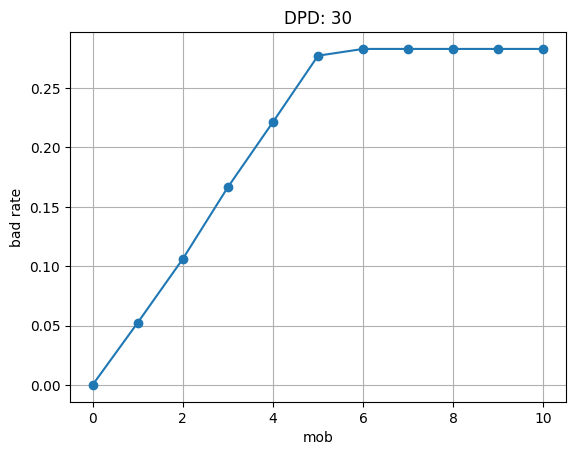

In [28]:
# set dpd label definition
dpd = 30

# Path to the folder containing CSV files
folder_path = silver_loan_daily_directory

# Read all CSV files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)

# filter only completed loans
df = df.filter(col("loan_start_date") < datetime.strptime("2024-01-01", "%Y-%m-%d"))

# create dpd flag if more than dpd
df = df.withColumn("dpd_flag", F.when(col("dpd") >= dpd, 1).otherwise(0))

# actual bads 
actual_bads_df = df.filter(col("installment_num") == 10)

# prepare for analysis
# df = df.filter(col("installment_num") < 10)

# visualise bad rate
pdf = df.toPandas()

# Group by col_A and count occurrences in col_B
grouped = pdf.groupby('mob')['dpd_flag'].mean()

# Sort the index (x-axis) of the grouped DataFrame
grouped = grouped.sort_index()

# Plotting
grouped.plot(kind='line', marker='o')

plt.title('DPD: '+ str(dpd))
plt.xlabel('mob')
plt.ylabel('bad rate')
plt.grid(True)
plt.show()


In [29]:
df.show()

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|mob|installments_missed|first_missed_date|dpd|dpd_flag|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|CUS_0x1011_2023_1...| CUS_0x1011|     2023-11-01|    10|             10| 10000.0| 1000.0|  1000.0|        0.0|    0.0|   2024-09-01| 10|                  0|             NULL|  0|       0|
|CUS_0x1013_2023_1...| CUS_0x1013|     2023-12-01|    10|              9| 10000.0| 1000.0|  1000.0|        0.0| 1000.0|   2024-09-01|  9|                  0|             NULL|  0|       0|
|CUS_0x1018_2023_1...| CUS_0x1018|     2023-11-01|    1

In [30]:
silver_clickstream_directory = "datamart/silver/clickstream/"

if not os.path.exists(silver_clickstream_directory):
    os.makedirs(silver_clickstream_directory)

In [31]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table_clickstream.process_silver_table(date_str, bronze_clickstream_directory, "clickstream", silver_clickstream_directory, spark)

loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_01_01.csv row count: 8974


saved to: datamart/silver/clickstream/clickstream2023_01_01.parquet
loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_02_01.csv row count: 8974


saved to: datamart/silver/clickstream/clickstream2023_02_01.parquet
loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_03_01.csv row count: 8974
saved to: datamart/silver/clickstream/clickstream2023_03_01.parquet
loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_04_01.csv row count: 8974
saved to: datamart/silver/clickstream/clickstream2023_04_01.parquet
loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_05_01.csv row count: 8974
saved to: datamart/silver/clickstream/clickstream2023_05_01.parquet
loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_06_01.csv row count: 8974
saved to: datamart/silver/clickstream/clickstream2023_06_01.parquet
loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_07_01.csv row count: 8974
saved to: datamart/silver/clickstream/clickstream2023_07_01.parquet
loaded from: datamart/bronze/clickstream/bronze_feature_clickstream_2023_08_01.csv row count: 897

## Build gold table for labels

In [32]:
# create bronze datalake
gold_label_store_directory = "datamart/gold/label_store/"

if not os.path.exists(gold_label_store_directory):
    os.makedirs(gold_label_store_directory)

In [33]:
# run gold backfill
for date_str in dates_str_lst:
    utils.data_processing_gold_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd = 30, mob = 6)


loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet row count: 530
saved to: datamart/gold/label_store/gold_label_store_2023_01_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet row count: 1031
saved to: datamart/gold/label_store/gold_label_store_2023_02_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_03_01.parquet row count: 1537
saved to: datamart/gold/label_store/gold_label_store_2023_03_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_04_01.parquet row count: 2047


saved to: datamart/gold/label_store/gold_label_store_2023_04_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_05_01.parquet row count: 2568
saved to: datamart/gold/label_store/gold_label_store_2023_05_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_06_01.parquet row count: 3085
saved to: datamart/gold/label_store/gold_label_store_2023_06_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_07_01.parquet row count: 3556
saved to: datamart/gold/label_store/gold_label_store_2023_07_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_08_01.parquet row count: 4037
saved to: datamart/gold/label_store/gold_label_store_2023_08_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_09_01.parquet row count: 4491
saved to: datamart/gold/label_store/gold_label_store_2023_09_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_10_01.parquet row count: 4978
saved to: 

In [34]:
utils.data_processing_gold_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd = 30, mob = 6).dtypes


loaded from: datamart/silver/loan_daily/silver_loan_daily_2025_01_01.parquet row count: 5539
saved to: datamart/gold/label_store/gold_label_store_2025_01_01.parquet


[('loan_id', 'string'),
 ('Customer_ID', 'string'),
 ('label', 'int'),
 ('label_def', 'string'),
 ('snapshot_date', 'date')]

## inspect label store

In [35]:
folder_path = gold_label_store_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
print("row_count:",df.count())

df.show()

row_count: 9479
+--------------------+-----------+-----+----------+-------------+
|             loan_id|Customer_ID|label| label_def|snapshot_date|
+--------------------+-----------+-----+----------+-------------+
|CUS_0x1037_2023_0...| CUS_0x1037|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1069_2023_0...| CUS_0x1069|    0|30dpd_6mob|   2023-07-01|
|CUS_0x114a_2023_0...| CUS_0x114a|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1184_2023_0...| CUS_0x1184|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1297_2023_0...| CUS_0x1297|    1|30dpd_6mob|   2023-07-01|
|CUS_0x12fb_2023_0...| CUS_0x12fb|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1325_2023_0...| CUS_0x1325|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1341_2023_0...| CUS_0x1341|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1375_2023_0...| CUS_0x1375|    1|30dpd_6mob|   2023-07-01|
|CUS_0x13a8_2023_0...| CUS_0x13a8|    0|30dpd_6mob|   2023-07-01|
|CUS_0x13ef_2023_0...| CUS_0x13ef|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1440_2023_0...| CUS_0x1440|    0|30dpd_6mob|   2023-0

In [36]:
df.printSchema()

root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- label_def: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



### Create Feature Store ###

In [37]:
# Feature engineering
silver_attributes_directory = "datamart/silver/attributes/"
gold_feature_store_directory = 'datamart/gold/feature_store/'

if not os.path.exists(gold_feature_store_directory):
    os.makedirs(gold_feature_store_directory)

for date_str in dates_str_lst:
    utils.data_processing_gold_table_features.process_gold_table(date_str, silver_attributes_directory, gold_feature_store_directory, spark)


loaded from: datamart/silver/attributes/attributes2023_01_01.parquet row count: 530
+-------------+----------------+---------------+
|occupation   |occupation_index|occupation_ohe |
+-------------+----------------+---------------+
|Teacher      |12.0            |(17,[12],[1.0])|
|Lawyer       |1.0             |(17,[1],[1.0]) |
|Entrepreneur |14.0            |(17,[14],[1.0])|
|Media_Manager|2.0             |(17,[2],[1.0]) |
|Entrepreneur |14.0            |(17,[14],[1.0])|
|Teacher      |12.0            |(17,[12],[1.0])|
|Scientist    |6.0             |(17,[6],[1.0]) |
|Developer    |5.0             |(17,[5],[1.0]) |
|Accountant   |7.0             |(17,[7],[1.0]) |
|Doctor       |8.0             |(17,[8],[1.0]) |
|Architect    |13.0            |(17,[13],[1.0])|
|Media_Manager|2.0             |(17,[2],[1.0]) |
|Journalist   |0.0             |(17,[0],[1.0]) |
|Media_Manager|2.0             |(17,[2],[1.0]) |
|Manager      |15.0            |(17,[15],[1.0])|
|Architect    |13.0            |(1

saved to: datamart/gold/feature_store/gold_feature_store_2023_07_01.parquet
loaded from: datamart/silver/attributes/attributes2023_08_01.parquet row count: 481
+----------+----------------+---------------+
|occupation|occupation_index|occupation_ohe |
+----------+----------------+---------------+
|Teacher   |4.0             |(17,[4],[1.0]) |
|Writer    |14.0            |(17,[14],[1.0])|
|Architect |15.0            |(17,[15],[1.0])|
|Teacher   |4.0             |(17,[4],[1.0]) |
|Developer |7.0             |(17,[7],[1.0]) |
|Mechanic  |2.0             |(17,[2],[1.0]) |
|Lawyer    |8.0             |(17,[8],[1.0]) |
|Scientist |5.0             |(17,[5],[1.0]) |
|Musician  |9.0             |(17,[9],[1.0]) |
|Lawyer    |8.0             |(17,[8],[1.0]) |
|Lawyer    |8.0             |(17,[8],[1.0]) |
|Musician  |9.0             |(17,[9],[1.0]) |
|_______   |3.0             |(17,[3],[1.0]) |
|Writer    |14.0            |(17,[14],[1.0])|
|Manager   |10.0            |(17,[10],[1.0])|
|Engineer  |

saved to: datamart/gold/feature_store/gold_feature_store_2024_07_01.parquet
loaded from: datamart/silver/attributes/attributes2024_08_01.parquet row count: 543
+------------+----------------+---------------+
|occupation  |occupation_index|occupation_ohe |
+------------+----------------+---------------+
|Architect   |11.0            |(17,[11],[1.0])|
|Musician    |13.0            |(17,[13],[1.0])|
|Musician    |13.0            |(17,[13],[1.0])|
|Musician    |13.0            |(17,[13],[1.0])|
|Accountant  |2.0             |(17,[2],[1.0]) |
|Entrepreneur|9.0             |(17,[9],[1.0]) |
|Entrepreneur|9.0             |(17,[9],[1.0]) |
|Entrepreneur|9.0             |(17,[9],[1.0]) |
|_______     |0.0             |(17,[0],[1.0]) |
|Manager     |15.0            |(17,[15],[1.0])|
|Developer   |8.0             |(17,[8],[1.0]) |
|Lawyer      |3.0             |(17,[3],[1.0]) |
|_______     |0.0             |(17,[0],[1.0]) |
|_______     |0.0             |(17,[0],[1.0]) |
|Scientist   |10.0      

saved to: datamart/gold/feature_store/gold_feature_store_2025_01_01.parquet


In [38]:
# Analyze snapshot_date capability
print("="*80)
print("FEATURES_FINANCIALS.CSV Analysis")
print("="*80)
df_financials = spark.read.csv("data/features_financials.csv", header=True, inferSchema=True)
print(f"Shape: {df_financials.count()} rows")
print(f"Columns: {df_financials.columns}")
print("\nFirst few rows:")
df_financials.show(5)

# Check for snapshot_date
if 'snapshot_date' in df_financials.columns:
    print(f"\nSnapshot_date found!")
    df_financials.select('Customer_ID', 'snapshot_date').distinct().count()
else:
    print(f"\n'snapshot_date' NOT found")
    date_cols = [col for col in df_financials.columns if 'date' in col.lower()]
    print(f"Available date columns: {date_cols}")

FEATURES_FINANCIALS.CSV Analysis
Shape: 12500 rows
Columns: ['Customer_ID', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'snapshot_date']

First few rows:
+-----------+------------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+------------------+-------------+
|Customer_ID|     Annual_Income|Monthly_Inhand_Sa

## Joining tables in silver layers into master feature file ##

In [42]:
# Define folder paths
gold_attr_path = 'datamart/gold/feature_store/'
silver_fin_path = 'datamart/silver/financials/'
silver_clickstream_path = 'datamart/silver/clickstream/'
silver_loan_path = 'datamart/silver/loan_daily/'

def load_all_parquets_in_dir(directory):
    if not os.path.exists(directory):
        print(f"Warning: Directory {directory} does not exist.")
        return None

    search_pattern = os.path.join(directory, "**/*.parquet")
    files = glob.glob(search_pattern, recursive=True)

    if not files:
        files = glob.glob(os.path.join(directory, "*"))

    if not files:
        print(f"Warning: No files found in {directory}")
        return None

    try:
        df = spark.read.option("mergeSchema", "true").parquet(*files)
    except Exception as e:
        print(f"Standard merge failed for {directory}, falling back to manual alignment...")
        dfs = []
        for f in files:
            temp_df = spark.read.parquet(f)
            if "Age" in temp_df.columns:
                temp_df = temp_df.withColumn("Age", col("Age").cast("string"))
            if "age" in temp_df.columns:
                temp_df = temp_df.withColumn("age", col("age").cast("string"))
            dfs.append(temp_df)

        from functools import reduce
        df = reduce(lambda df1, df2: df1.unionByName(df2, allowMissingColumns=True), dfs)

    if "Age" in df.columns:
        df = df.withColumn("Age", col("Age").cast("double"))
    elif "age" in df.columns:
        df = df.withColumn("age", col("age").cast("double"))

    return df

print("Loading and aggregating monthly files... ")

df_gold_attr = load_all_parquets_in_dir(gold_attr_path)
df_silver_fin = load_all_parquets_in_dir(silver_fin_path)
df_silver_clickstream = load_all_parquets_in_dir(silver_clickstream_path)
df_silver_loan = load_all_parquets_in_dir(silver_loan_path)

if df_gold_attr is not None:
    master_df = df_gold_attr

    if df_silver_fin is not None:
        # Identify overlapping columns to avoid duplication
        overlap_cols = [c for c in df_silver_fin.columns if c in master_df.columns and c not in ["Customer_ID", "snapshot_date"]]
        df_silver_fin_clean = df_silver_fin.drop(*overlap_cols)
        master_df = master_df.join(df_silver_fin_clean, on=["Customer_ID", "snapshot_date"], how="left")

    if df_silver_clickstream is not None:
        # Identify overlapping columns to avoid duplication
        overlap_cols = [c for c in df_silver_clickstream.columns if c in master_df.columns and c not in ["Customer_ID", "snapshot_date"]]
        df_silver_clickstream_clean = df_silver_clickstream.drop(*overlap_cols)
        master_df = master_df.join(df_silver_clickstream_clean, on=["Customer_ID", "snapshot_date"], how="left")

    if df_silver_loan is not None:
        overlap_cols_loan = [c for c in df_silver_loan.columns if c in master_df.columns and c not in ["Customer_ID", "snapshot_date"]]
        df_silver_loan_clean = df_silver_loan.drop(*overlap_cols_loan)
        master_df = master_df.join(df_silver_loan_clean, on=["Customer_ID", "snapshot_date"], how="left")

    print(f"Aggregation complete. Row Count: {master_df.count()}")
    master_df.select("Customer_ID", "snapshot_date", "Age", "Occupation").show(10)
else:
    print("Error: Primary Gold Attributes table could not be loaded.")

Loading and aggregating monthly files... 


26/05/21 13:18:06 ERROR Executor: Exception in task 7.0 in stage 3452.0 (TID 3066)
org.apache.spark.SparkException: [CANNOT_MERGE_SCHEMAS] Failed merging schemas:
Initial schema:
"STRUCT<Customer_ID: STRING, Name: STRING, age: DOUBLE, SSN: STRING, Occupation: STRING, snapshot_date: DATE, occupation_index: DOUBLE, occupation_ohe: STRUCT<type: TINYINT, size: INT, indices: ARRAY<INT>, values: ARRAY<DOUBLE>>, age_squared: DOUBLE>"
Schema that cannot be merged with the initial schema:
"STRUCT<Customer_ID: STRING, snapshot_date: DATE, Annual_Income: STRING, Monthly_Inhand_Salary: DOUBLE, Num_Bank_Accounts: INT, Num_Credit_Card: INT, Interest_Rate: INT, Num_of_Loan: STRING, Type_of_Loan: STRING, Delay_from_due_date: INT, Num_of_Delayed_Payment: STRING, Changed_Credit_Limit: STRING, Num_Credit_Inquiries: DOUBLE, Credit_Mix: STRING, Outstanding_Debt: STRING, Credit_Utilization_Ratio: DOUBLE, Credit_History_Age: STRING, Payment_of_Min_Amount: STRING, Total_EMI_per_month: DOUBLE, Amount_invested_

Standard merge failed for datamart/gold/feature_store/, falling back to manual alignment...


26/05/21 13:18:17 ERROR Executor: Exception in task 7.0 in stage 3507.0 (TID 3233)
org.apache.spark.SparkException: [CANNOT_MERGE_SCHEMAS] Failed merging schemas:
Initial schema:
"STRUCT<fe_1: INT, fe_2: INT, fe_3: INT, fe_4: INT, fe_5: INT, fe_6: INT, fe_7: INT, fe_8: INT, fe_9: INT, fe_10: INT, fe_11: INT, fe_12: INT, fe_13: INT, fe_14: INT, fe_15: INT, fe_16: INT, fe_17: INT, fe_18: INT, fe_19: INT, fe_20: INT, Customer_ID: STRING, snapshot_date: DATE>"
Schema that cannot be merged with the initial schema:
"STRUCT<fe_1: STRING, fe_2: STRING, fe_3: STRING, fe_4: STRING, fe_5: STRING, fe_6: STRING, fe_7: STRING, fe_8: STRING, fe_9: STRING, fe_10: STRING, fe_11: STRING, fe_12: STRING, fe_13: STRING, fe_14: STRING, fe_15: STRING, fe_16: STRING, fe_17: STRING, fe_18: STRING, fe_19: STRING, fe_20: STRING, Customer_ID: STRING, snapshot_date: STRING>".
	at org.apache.spark.sql.errors.QueryExecutionErrors$.failedMergingSchemaError(QueryExecutionErrors.scala:2176)
	at org.apache.spark.sql.exe

Standard merge failed for datamart/silver/clickstream/, falling back to manual alignment...


Aggregation complete. Row Count: 257688


+-----------+-------------+----+----------+
|Customer_ID|snapshot_date| Age|Occupation|
+-----------+-------------+----+----------+
| CUS_0x47a5|   2023-01-01|32.0|   Teacher|
| CUS_0x47a5|   2023-01-01|32.0|   Teacher|
| CUS_0x47a5|   2023-01-01|32.0|   Teacher|
| CUS_0x47a5|   2023-01-01|32.0|   Teacher|
| CUS_0x47a5|   2023-01-01|32.0|   Teacher|
| CUS_0x47a5|   2023-01-01|32.0|   Teacher|
| CUS_0x47a5|   2023-01-01|32.0|   Teacher|
| CUS_0x47a5|   2023-01-01|32.0|   Teacher|
| CUS_0x51c9|   2023-01-01|29.0|    Lawyer|
| CUS_0x51c9|   2023-01-01|29.0|    Lawyer|
+-----------+-------------+----+----------+
only showing top 10 rows



In [43]:
# Define the output path for the Master ABT
master_feature_output_path = 'datamart/gold/feature_store/master_feature/'

if not os.path.exists(master_feature_output_path):
    os.makedirs(master_feature_output_path)

print(f"Saving Master feature partitioned by snapshot_date to {master_feature_output_path}...")

# Save the Master ABT partitioned by month to align with label storage
master_df.write.mode("overwrite").partitionBy("snapshot_date").parquet(master_feature_output_path)

print("Master feature successfully persisted to Gold layer and partitioned by month.")

Saving Master feature partitioned by snapshot_date to datamart/gold/feature_store/master_feature/...


Master feature successfully persisted to Gold layer and partitioned by month.


### 4-Way Temporal Split: Train, Validation, Test and OOT Sets
1. Train Set: Data before 2024-01-01.
2. Validation Set: Data from 2024-01-01 to 2024-06-30.
3. Test Set: A dedicated test partition.
4. OOT (Out-of-Time) Set: The final evaluation set from 2024-07-01 onwards to ensure strict temporal isolation.

In [44]:
# Define split points
val_split_date = "2024-01-01"
test_oot_split_date = "2024-07-01"

# 1. Training Set
train_df = master_df.filter(col("snapshot_date") < val_split_date)

# 2. Validation Set
val_df = master_df.filter((col("snapshot_date") >= val_split_date) & (col("snapshot_date") < "2024-04-01"))

# 3. Test Set (In-time/Close-time test)
test_df = master_df.filter((col("snapshot_date") >= "2024-04-01") & (col("snapshot_date") < test_oot_split_date))

# 4. OOT Set (Out-of-Time Final Evaluation)
oot_df = master_df.filter(col("snapshot_date") >= test_oot_split_date)

# Summary of counts
print(f"Train records:      {train_df.count()}")
print(f"Validation records: {val_df.count()}")
print(f"Test records:       {test_df.count()}")
print(f"OOT records:        {oot_df.count()}")

# Verify time ranges
def get_range(df):
    rng = df.select(F.min("snapshot_date"), F.max("snapshot_date")).collect()[0]
    return f"{rng[0]} to {rng[1]}"

print(f"\nTrain Range:      {get_range(train_df)}")
print(f"Validation Range: {get_range(val_df)}")
print(f"Test Range:       {get_range(test_df)}")
print(f"OOT Range:        {get_range(oot_df)}")

Train records:      142992


Validation records: 36336


Test records:       36048


OOT records:        42312



Train Range:      2023-01-01 to 2023-12-01


Validation Range: 2024-01-01 to 2024-03-01


Test Range:       2024-04-01 to 2024-06-01


[Stage 3610:======================================>               (36 + 8) / 51]

OOT Range:        2024-07-01 to 2025-01-01
